## Empirische Verteilung der relativen Häufigkeit $H=X/n$

Für ein festes $p_0$ werden wiederholt Stichproben simuliert. In jeder Stichprobe gilt

$$
X\sim B(n,p_0)
\qquad\text{und}\qquad
H=\frac{X}{n}.
$$

Jeder Punkt steht für eine Realisation von $H$. Gleiche Werte werden übereinander gestapelt. Damit liegt $h$ zunächst in der vertrauten Orientierung auf der horizontalen Achse. Erst in der Datei zur Verfahrenswahrscheinlichkeit wird diese Darstellung in den $(p,h)$-Raum gedreht.

Auf Wunsch wird das normalapproximative Prognoseintervall auf der $h$-Achse eingezeichnet. Punkte außerhalb können rot markiert werden. Eine Ergebniszahl wird bewusst nicht ausgegeben: Die Grafik bleibt ein **Denkraum**.

## Eingaben

Nur die folgende Zelle muss verändert werden. Die Klasse `Config` bündelt vier Arten von Eingaben:

- mathematische und simulationsbezogene Eingaben,
- Ausschnitt und Elemente der Grafik,
- Beschriftung,
- Anzeige und Speicherung.

`point_size` verändert die Größe der Punkte. `horizontal_spacing` ist ein Faktor für die Breite der Abbildung: Ein Wert von `1.2` macht die Abbildung um $20\,\%$ breiter und vergrößert damit den sichtbaren Abstand der Punktspalten. Die mathematischen Positionen $h=k/n$ bleiben dabei unverändert.

Für `x_min` und `x_max` kann jeweils eine Zahl oder `None` eingegeben werden. Bei `None` wird die Grenze aus den simulierten Werten und dem Prognoseintervall automatisch bestimmt.

In [17]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np


plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})


@dataclass(frozen=True)
class Config:
    # Mathematische und simulationsbezogene Eingaben
    n: int = 400
    p0: float = 0.15
    gamma: float = 0.90
    number_of_samples: int = 100
    seed: int = 7

    # Ausschnitt und Elemente der Grafik
    x_min: float | None = None
    x_max: float | None = None
    x_tick_step: float = 0.01
    x_padding: float = 0.01
    show_prediction_interval: bool = True
    color_outside: bool = True
    point_size: float = 100.0
    horizontal_spacing: float = 1.0

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True

    # Ausgabe des Notebooks
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung, Simulation und mathematische Berechnung

Zunächst werden die Eingaben geprüft. Danach simuliert `simulate_hits()` die Trefferzahlen. Die Funktion `prediction_interval()` berechnet das normalapproximative Prognoseintervall

$$
p_0\pm z\sqrt{\frac{p_0(1-p_0)}{n}},
$$

wobei $z$ das Quantil zum zentralen Wahrscheinlichkeitsinhalt $\gamma$ ist. Schließlich erzeugt `dotplot_positions()` aus den Trefferzahlen die Positionen der Punkte.

Simulation, Intervallberechnung und Stapelung greifen nicht auf globale Zwischenwerte zu.

In [18]:
@dataclass(frozen=True)
class Calculation:
    z: float
    hits: np.ndarray
    relative_frequencies: np.ndarray
    prediction_lower: float
    prediction_upper: float
    dotplot_h: np.ndarray
    dotplot_level: np.ndarray
    dotplot_inside: np.ndarray
    maximum_multiplicity: int


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not 0.0 <= cfg.p0 <= 1.0:
        raise ValueError("p0 muss zwischen 0 und 1 liegen.")
    if not 0.0 < cfg.gamma < 1.0:
        raise ValueError("gamma muss zwischen 0 und 1 liegen.")
    if (
        not isinstance(cfg.number_of_samples, int)
        or isinstance(cfg.number_of_samples, bool)
        or cfg.number_of_samples <= 0
    ):
        raise ValueError("number_of_samples muss eine positive ganze Zahl sein.")
    if not isinstance(cfg.seed, int) or isinstance(cfg.seed, bool) or cfg.seed < 0:
        raise ValueError("seed muss eine nichtnegative ganze Zahl sein.")

    for name, value in (("x_min", cfg.x_min), ("x_max", cfg.x_max)):
        if value is not None and not 0.0 <= value <= 1.0:
            raise ValueError(f"{name} muss zwischen 0 und 1 liegen oder None sein.")
    if (
        cfg.x_min is not None
        and cfg.x_max is not None
        and cfg.x_min >= cfg.x_max
    ):
        raise ValueError("Es muss x_min < x_max gelten.")
    if cfg.x_tick_step <= 0.0:
        raise ValueError("x_tick_step muss positiv sein.")
    if cfg.x_padding < 0.0:
        raise ValueError("x_padding darf nicht negativ sein.")
    if cfg.point_size <= 0.0:
        raise ValueError("point_size muss positiv sein.")
    if cfg.horizontal_spacing <= 0.0:
        raise ValueError("horizontal_spacing muss positiv sein.")

    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")
    if Path(cfg.output_dir).is_absolute():
        raise ValueError("output_dir muss ein relativer Pfad sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    if cfg.save_figure and not formats:
        raise ValueError("save_formats darf beim Speichern nicht leer sein.")
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def simulate_hits(
    *,
    n: int,
    p0: float,
    number_of_samples: int,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.binomial(n, p0, size=number_of_samples)


def prediction_interval(
    *,
    n: int,
    p0: float,
    z: float,
) -> tuple[float, float]:
    half_width = z * np.sqrt(p0 * (1.0 - p0) / n)
    return p0 - half_width, p0 + half_width


def dotplot_positions(
    hits: np.ndarray,
    *,
    n: int,
) -> tuple[np.ndarray, np.ndarray, int]:
    # Gleiche h-Werte werden von der h-Achse aus nach oben gestapelt.
    h_points: list[float] = []
    levels: list[int] = []
    maximum_multiplicity = 0

    counts = Counter(int(k) for k in hits)
    for k, multiplicity in sorted(counts.items()):
        h_points.extend([k / n] * multiplicity)
        levels.extend(range(1, multiplicity + 1))
        maximum_multiplicity = max(maximum_multiplicity, multiplicity)

    return (
        np.asarray(h_points),
        np.asarray(levels),
        maximum_multiplicity,
    )


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    z = NormalDist().inv_cdf((1.0 + cfg.gamma) / 2.0)
    hits = simulate_hits(
        n=cfg.n,
        p0=cfg.p0,
        number_of_samples=cfg.number_of_samples,
        seed=cfg.seed,
    )
    relative_frequencies = hits / cfg.n
    prediction_lower, prediction_upper = prediction_interval(
        n=cfg.n,
        p0=cfg.p0,
        z=z,
    )
    dotplot_h, dotplot_level, maximum_multiplicity = dotplot_positions(
        hits,
        n=cfg.n,
    )
    dotplot_inside = (
        (prediction_lower <= dotplot_h)
        & (dotplot_h <= prediction_upper)
    )

    return Calculation(
        z=z,
        hits=hits,
        relative_frequencies=relative_frequencies,
        prediction_lower=prediction_lower,
        prediction_upper=prediction_upper,
        dotplot_h=dotplot_h,
        dotplot_level=dotplot_level,
        dotplot_inside=dotplot_inside,
        maximum_multiplicity=maximum_multiplicity,
    )

## Grafik

`create_figure()` erzeugt ausschließlich die Grafik. Das Prognoseintervall, die Färbung der Punkte außerhalb sowie Titel und Untertitel können unabhängig voneinander ein- und ausgeblendet werden.

Das Prognoseintervall liegt als blaue Strecke unmittelbar auf der $h$-Achse. Der Untertitel enthält nur Eingaben. Weder die Intervallgrenzen noch die Anzahl der roten Punkte werden ausgegeben.

Der Parameter `horizontal_spacing` verändert nur die physische Breite der Abbildung. Die Punkte bleiben exakt über den diskreten Werten $h=k/n$.

In [19]:
def axis_limits(
    cfg: Config,
    calculation: Calculation,
) -> tuple[float, float]:
    data_lower = min(
        float(np.min(calculation.dotplot_h)),
        calculation.prediction_lower,
    )
    data_upper = max(
        float(np.max(calculation.dotplot_h)),
        calculation.prediction_upper,
    )

    automatic_lower = max(
        0.0,
        np.floor(
            (data_lower - cfg.x_padding) / cfg.x_tick_step
        )
        * cfg.x_tick_step,
    )
    automatic_upper = min(
        1.0,
        np.ceil(
            (data_upper + cfg.x_padding) / cfg.x_tick_step
        )
        * cfg.x_tick_step,
    )

    lower = automatic_lower if cfg.x_min is None else cfg.x_min
    upper = automatic_upper if cfg.x_max is None else cfg.x_max
    if lower >= upper:
        raise ValueError("Die sichtbaren Achsengrenzen ergeben kein Intervall.")
    return float(lower), float(upper)


def x_tick_values(
    lower: float,
    upper: float,
    *,
    step: float,
) -> np.ndarray:
    first = np.ceil((lower - 1e-12) / step) * step
    last = np.floor((upper + 1e-12) / step) * step
    return np.arange(first, last + 0.5 * step, step)


def decimal_places(step: float) -> int:
    if step >= 1.0:
        return 0
    return min(4, max(1, int(np.ceil(-np.log10(step) - 1e-12))))


def format_decimal(value: float, *, step: float) -> str:
    if np.isclose(value, 0.0):
        return "0"
    places = decimal_places(step)
    return f"{value:.{places}f}".replace(".", ",")


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[Figure, Axes]:
    figure_width = 10.2 * cfg.horizontal_spacing
    fig, ax = plt.subplots(figsize=(figure_width, 4.))

    if cfg.color_outside:
        ordinary = calculation.dotplot_inside
    else:
        ordinary = np.ones_like(calculation.dotplot_inside, dtype=bool)

    ax.scatter(
        calculation.dotplot_h[ordinary],
        calculation.dotplot_level[ordinary],
        s=cfg.point_size,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=3,
    )

    if cfg.color_outside:
        ax.scatter(
            calculation.dotplot_h[~calculation.dotplot_inside],
            calculation.dotplot_level[~calculation.dotplot_inside],
            s=cfg.point_size,
            facecolors="red",
            edgecolors="black",
            linewidths=1.2,
            zorder=4,
        )

    if cfg.show_prediction_interval:
        ax.hlines(
            0.0,
            calculation.prediction_lower,
            calculation.prediction_upper,
            color="0.35",
            linewidth=9.0,
            zorder=5,
        )
        ax.vlines(
            [calculation.prediction_lower, calculation.prediction_upper],
            0.0,
            0.28,
            color="tab:blue",
            linewidth=3.0,
            zorder=5,
        )

    lower, upper = axis_limits(cfg, calculation)
    ax.set_xlim(lower, upper)
    ax.set_ylim(0.0, calculation.maximum_multiplicity + 1.0)
    ax.set_xticks(
        x_tick_values(lower, upper, step=cfg.x_tick_step)
    )
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, _position: format_decimal(
                value,
                step=cfg.x_tick_step,
            )
        )
    )
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel(rf"$h=k/{cfg.n}$", fontsize=18, labelpad=7)
    ax.set_ylabel("Anzahl", fontsize=18, labelpad=8)
    ax.tick_params(axis="both", labelsize=13, length=4, width=0.8)
    for spine in ax.spines.values():
        spine.set_color("0.25")
        spine.set_linewidth(0.8)

    title = r"Empirische Verteilung von $H=X/n$"
    subtitle = (
        rf"$n={cfg.n},\quad p_0={cfg.p0:.2f},\quad "
        rf"\gamma={cfg.gamma:.2f}$; "
        f"{cfg.number_of_samples} Stichproben; Seed = {cfg.seed}"
    )

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=16, pad=32)
        ax.text(
            0.5,
            1.03,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=12,
            color="0.25",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=16, pad=13)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=12, color="0.35", pad=13)

    fig.tight_layout()
    return fig, ax

## Ausgabe

Berechnung, Erzeugung der Grafik sowie Anzeige und Speicherung bleiben getrennt. Die Grafik kann unabhängig voneinander angezeigt und gespeichert werden.

Ist `save_figure = True`, wird der relative Unterordner `fig/` bei Bedarf automatisch angelegt. PNG- und PDF-Dateien werden dort gesammelt; das Verzeichnis des Notebooks bleibt frei von einzelnen Grafikdateien.

Der Dateiname wird automatisch aus den mathematischen und simulationsbezogenen Eingaben gebildet. Für die Standardeinstellungen entstehen

- `Empirische-H-Verteilung-n100-p027-gamma090-stichproben50-seed7.png`,
- `Empirische-H-Verteilung-n100-p027-gamma090-stichproben50-seed7.pdf`.

Die letzte Zelle zeigt ausschließlich die Grafik. Sie gibt weder die Intervallgrenzen noch die Anzahl der markierten Fälle aus.

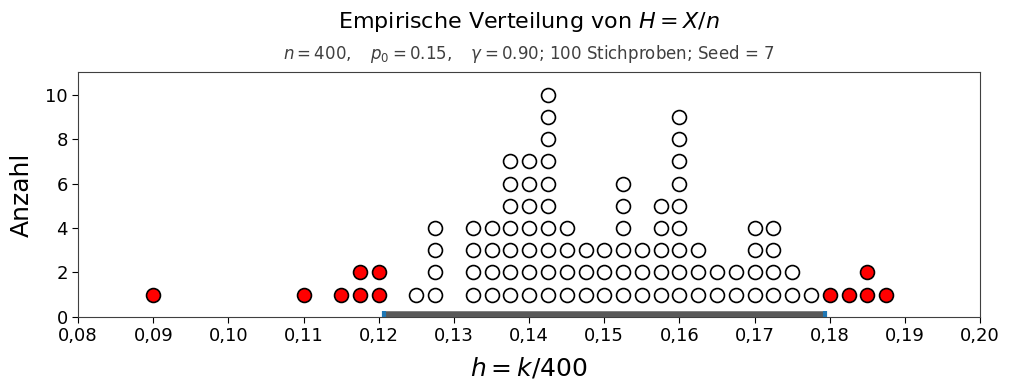

In [20]:
def probability_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    integer, separator, decimals = text.partition(".")
    decimals = decimals.ljust(2, "0") if separator else "00"
    return f"{integer}{decimals}".replace("-", "m")


def figure_stem(cfg: Config) -> str:
    p0 = probability_token(cfg.p0)
    gamma = probability_token(cfg.gamma)
    return (
        f"Empirische-H-Verteilung-n{cfg.n}-p{p0}-"
        f"gamma{gamma}-stichproben{cfg.number_of_samples}-seed{cfg.seed}"
    )


def save_figure(
    fig: Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)